<a href="https://colab.research.google.com/github/Muzzikon/WWML/blob/main/WWML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The first 3 weeks

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Генерация данных

def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)

    mean_area = 50  # Средняя площадь
    std_area = 20   # Стандартное отклонение площади
    S = round(np.random.normal(mean_area, std_area), 1)
    S = max(S, 10)  # Площадь не может быть меньше 10 м^2

    base_m2_price = 150000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))
    final_m2_price = base_m2_price * loc_coeff * dist_coeff

    total_price = (int((S * final_m2_price) * random.uniform(0.95, 1.05)) // 10000) * 10000
    total_vis_price = str(total_price)[:-6] + '.' + str(total_price)[-6:-3] + '.' + str(total_price)[-4:-1]
    information = {
        "район": location,
        "площадь m^2": S,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor,
        "цена": total_price}

    return information

# Создание файла с данными
def generate_data(n=1000):
    data = [generate_apartment() for _ in range(n)]
    return pd.DataFrame(data)

if __name__ == "__main__":
    data_set = generate_data()
    data_set.to_csv('dataset.csv', index=False)

In [3]:
# Показ данных

data_set = generate_data(1000)  # Генерируем сразу 1000 записей
pd.set_option('display.expand_frame_repr', False)  # Запретить перенос строк
pd.set_option('display.max_columns', None)       # Показывать все столбцы

print (data_set)

     район  площадь m^2  кол-во комнат  удаленность от центра (км)  этаж      цена
0        5         40.1              2                       19.83     3   4480000
1        9         69.2              1                        6.84    10   6810000
2        2         49.7              2                       15.61    14   7740000
3        9         25.3              5                       14.99    14   2080000
4        6         62.7              3                       11.02    21   7830000
..     ...          ...            ...                         ...   ...       ...
995      1         40.2              1                       13.38    10   7180000
996      5         59.0              5                       12.99     4   7490000
997      3         60.1              3                        5.48    13  11400000
998      7         68.4              2                       13.19     2   7860000
999      8         85.7              4                        9.15    18   9610000

[10

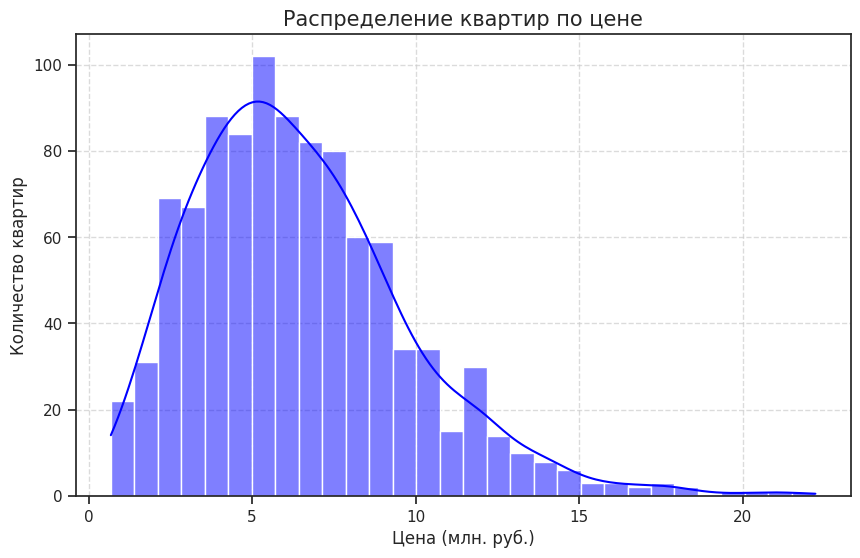

In [4]:
# Гистограмма

sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(10,6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color='blue')
plt.title("Распределение квартир по цене",fontsize=15)
plt.xlabel("Цена (млн. руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

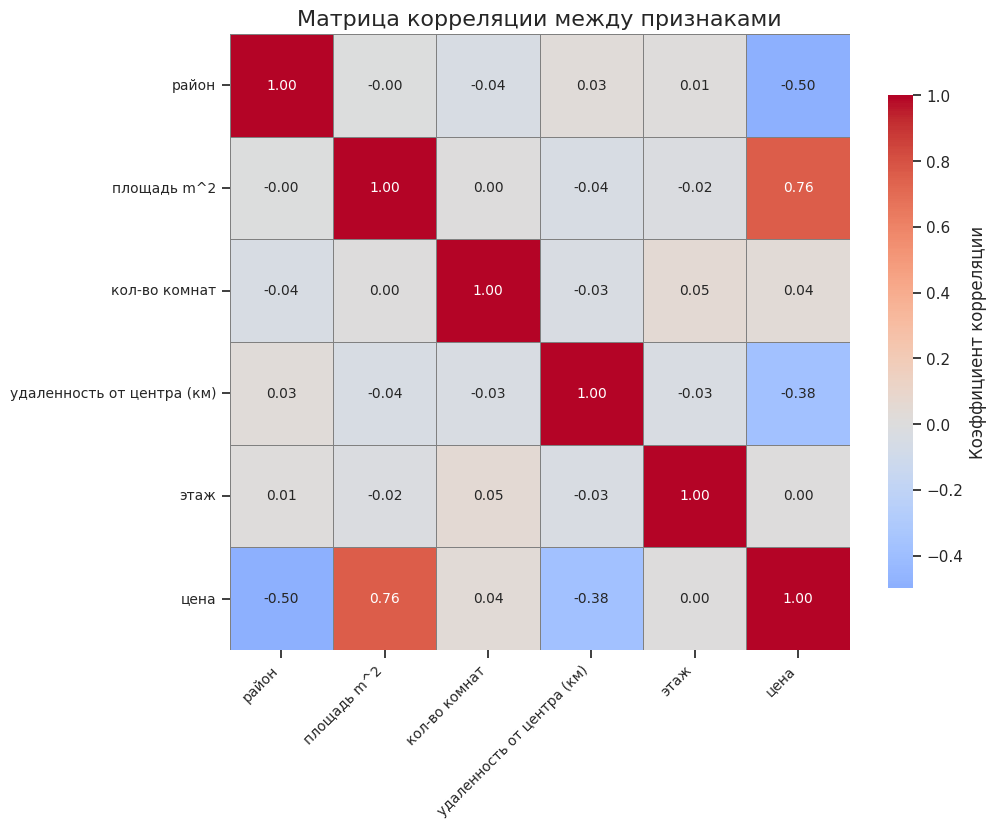

In [5]:
# Матрица корреляции

correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            fmt='.2f',
            annot_kws={'size': 10},

            linewidths=0.5,
            linecolor='gray')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Матрица корреляции между признаками", fontsize=16)
plt.show()

# The second 3 weeks

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [8]:
# Обучение модели
data_set = pd.read_csv('dataset.csv')

# Функция обучения и оценки модели
def train_and_evaluate(data, model_name):
    X = data.drop(columns=["цена"])
    y = data["цена"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print(f"Количество строк: {len(data)}")
    print(f"MAE: {mae:,.2f}")
    print(f"R2: {r2:.4f}")

    return model, mae, r2

# 1. Базовая модель
base_model, base_mae, base_r2 = train_and_evaluate(data_set, "Базовая модель")

# 2. Очистка выбросов по IQR для цены и площади
cleaned_data = data_set.copy()

for column in ["цена", "площадь m^2"]:
    Q1 = cleaned_data[column].quantile(0.25)
    Q3 = cleaned_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_data = cleaned_data[
        (cleaned_data[column] >= lower_bound) &
        (cleaned_data[column] <= upper_bound)
    ]

# 3. Модель после очистки выбросов
clean_model, clean_mae, clean_r2 = train_and_evaluate(cleaned_data, "Модель после удаления выбросов")

# 4. Сравнение и сохранение лучшей модели
if clean_r2 > base_r2:
    best_model = clean_model
    print("\nЛучшая модель: после удаления выбросов")
else:
    best_model = base_model
    print("\nЛучшая модель: базовая")

joblib.dump(best_model, "price_prediction_model.pkl")
print("Лучшая модель сохранена в файл price_prediction_model.pkl")


Базовая модель
Количество строк: 1000
MAE: 597,951.21
R2: 0.9382

Модель после удаления выбросов
Количество строк: 973
MAE: 526,139.07
R2: 0.9415

Лучшая модель: после удаления выбросов
Лучшая модель сохранена в файл price_prediction_model.pkl
